**Importing Dataset**

In [25]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

#SMART ZIP EXTRACTION
zip_filename = "/content/drive/MyDrive/AI & ML /FruitinAmazon.zip"

print("🔍 Looking for the dataset zip file...")

if os.path.exists(zip_filename):
    print(f"📦 Found {zip_filename}. Extracting...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")          # Extract everything
    print("✅ Extraction completed!")
else:
    print(f"⚠️ {zip_filename} not found in the current folder.")
    print("Please upload FruitinAmazon.zip and run this cell again.")
    raise FileNotFoundError("Zip file not found.")

# AUTO-DETECT train/ and test/ folders
def find_dataset_folders():
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs and 'test' in dirs:
            train_path = os.path.join(root, 'train')
            test_path = os.path.join(root, 'test')
            print(f"✅ Found dataset at: {root}")
            return train_path, test_path
    # Fallback: look for any folder named 'train'
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs:
            return os.path.join(root, 'train'), None
    return None, None

train_dir, test_dir = find_dataset_folders()

if train_dir and os.path.exists(train_dir):
    print(f"Train folder set to: {train_dir}")
else:
    print("Could not find 'train' folder even after extraction.")
    print("Please check the zip structure and tell me what folders you see after extraction.")

if test_dir and os.path.exists(test_dir):
    print(f"Test folder set to : {test_dir}")
else:
    print("'test' folder not found (some datasets have only train). Using validation split instead.")

%matplotlib inline
plt.style.use('seaborn-v0_8')
print("Setup complete! You can now run the next cells.")

🔍 Looking for the dataset zip file...
📦 Found /content/drive/MyDrive/AI & ML /FruitinAmazon.zip. Extracting...
✅ Extraction completed!
✅ Found dataset at: ./FruitinAmazon
Train folder set to: ./FruitinAmazon/train
Test folder set to : ./FruitinAmazon/test
Setup complete! You can now run the next cells.


**Task 1: Data Understanding and Visualization:**

Found 6 classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


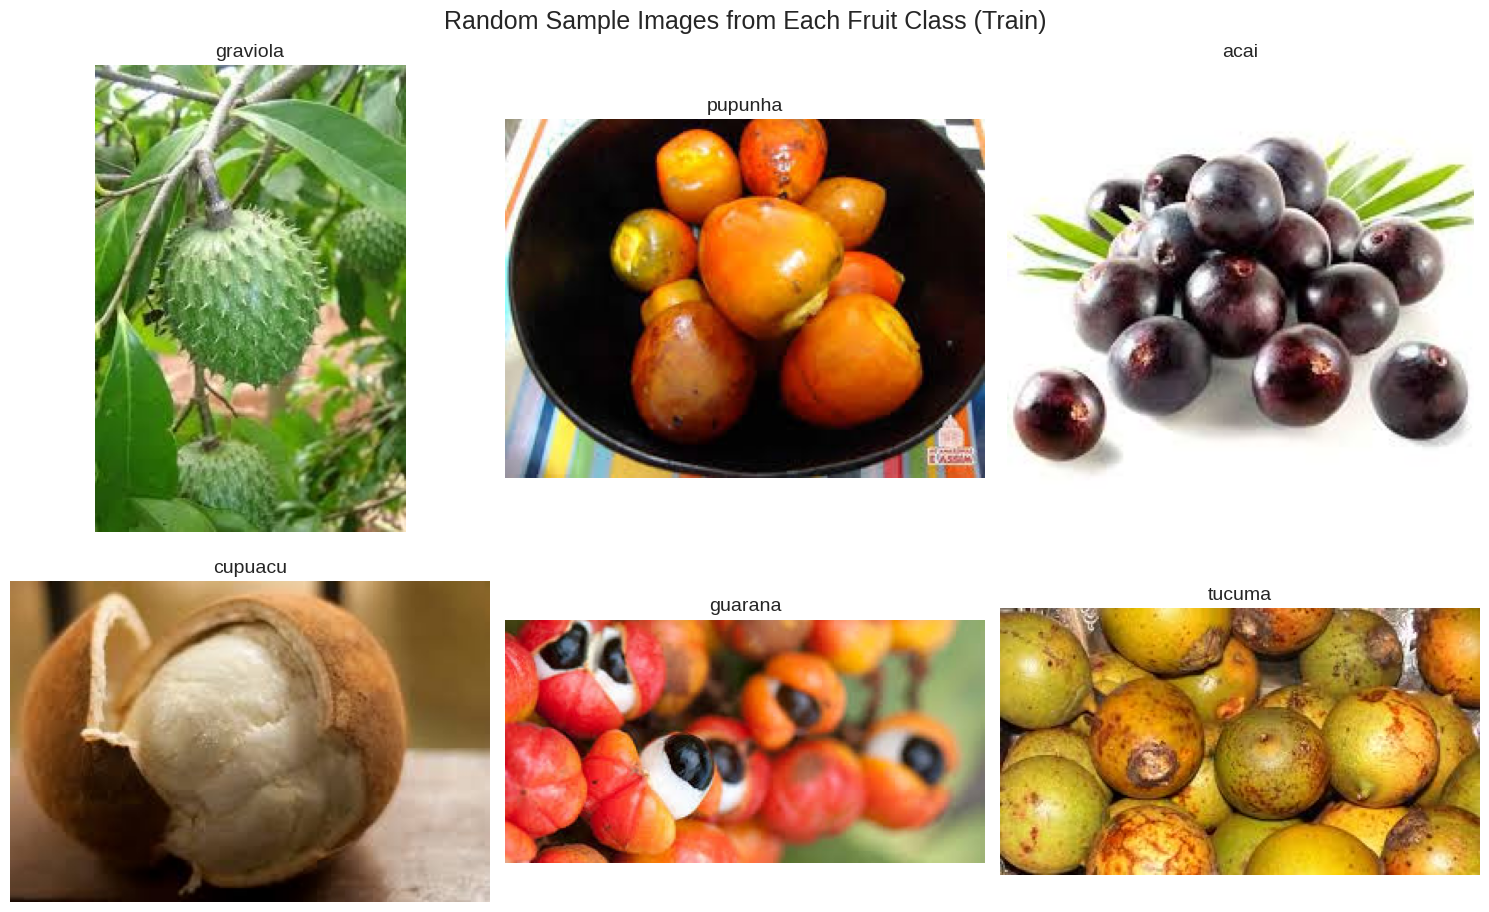

In [27]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print(f"Found {len(classes)} classes: {classes}")

images_to_show = []
labels_to_show = []

for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if img_files:
        img_file = random.choice(img_files)
        img_path = os.path.join(class_dir, img_file)
        images_to_show.append(img_path)
        labels_to_show.append(cls)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Random Sample Images from Each Fruit Class (Train)', fontsize=18)

for i, ax in enumerate(axes.flat):
    if i < len(images_to_show):
        img = Image.open(images_to_show[i])
        ax.imshow(img)
        ax.set_title(labels_to_show[i], fontsize=14)
        ax.axis('off')

plt.tight_layout()
plt.show()

**Check for Corrupted Image**

In [28]:
def check_corrupted(train_dir):
    corrupted = []
    for cls in os.listdir(train_dir):
        class_dir = os.path.join(train_dir, cls)
        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):
                img_path = os.path.join(class_dir, filename)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except (UnidentifiedImageError, IOError, SyntaxError):
                    corrupted.append(img_path)
                    os.remove(img_path)
                    print(f"🗑 Removed: {img_path}")
    print("✅ No corrupted images found." if not corrupted else f"Removed {len(corrupted)} corrupted images.")
check_corrupted(train_dir)

✅ No corrupted images found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [29]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# 1. Create datasets FIRST (before mapping)
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# 2. Get class_names BEFORE applying map (this is the fix)
class_names = raw_train_ds.class_names
num_classes = len(class_names)

# 3. Now apply normalization
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = raw_val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = raw_test_ds.map(lambda x, y: (rescale(x), y))

print(f"✅ Classes: {class_names}")
print(f"Training samples : {len(train_ds) * batch_size}")
print(f"Validation samples: {len(val_ds) * batch_size}")
print(f"Test samples     : {len(test_ds) * batch_size}")
print("✅ Datasets loaded and normalized successfully!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
✅ Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Training samples : 80
Validation samples: 32
Test samples     : 32
✅ Datasets loaded and normalized successfully!


**Task 3 - Implement a CNN with**
**Follow the following Structure and Hyper - parameters:**

In [31]:
#TASK 3: CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                           input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Compile the Model**

In [32]:
#TASK 4: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_fruit_model.h5', monitor='val_loss',
                             save_best_only=True, mode='min', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)

history = model.fit(train_ds, epochs=250, validation_data=val_ds,
                    callbacks=[checkpoint, early_stop])

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.1260 - loss: 1.9504
Epoch 1: val_loss improved from None to 2.08373, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step - accuracy: 0.1250 - loss: 1.9449 - val_accuracy: 0.0556 - val_loss: 2.0837
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.3031 - loss: 1.6135
Epoch 2: val_loss improved from 2.08373 to 1.49583, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.2917 - loss: 1.5908 - val_accuracy: 0.4444 - val_loss: 1.4958
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.3844 - loss: 1.4528
Epoch 3: val_loss improved from 1.49583 to 1.24723, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.4167 - loss: 1.3641 - val_accuracy: 0.7222 - val_loss: 1.2472
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7080 - loss: 0.9860
Epoch 4: val_loss did not improve from 1.24723
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 0.6806 - loss: 1.0041 - val_accuracy: 0.5000 - val_loss: 1.4173
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8764 - loss: 0.7020
Epoch 5: val_loss improved from 1.24723 to 0.53145, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.8611 - loss: 0.6917 - val_accuracy: 0.9444 - val_loss: 0.5314
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8903 - loss: 0.5280
Epoch 6: val_loss did not improve from 0.53145
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.8889 - loss: 0.5985 - val_accuracy: 0.8333 - val_loss: 0.8533
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8719 - loss: 0.3566
Epoch 7: val_loss improved from 0.53145 to 0.38917, saving model to best_fruit_model.h5



Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.8750 - loss: 0.3878 - val_accuracy: 0.8889 - val_loss: 0.3892
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9396 - loss: 0.2214
Epoch 8: val_loss did not improve from 0.38917
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.9167 - loss: 0.2504 - val_accuracy: 0.8333 - val_loss: 0.5050
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9736 - loss: 0.1223
Epoch 9: val_loss improved from 0.38917 to 0.35594, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.9722 - loss: 0.1388 - val_accuracy: 0.8333 - val_loss: 0.3559
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9712 - loss: 0.0683
Epoch 10: val_loss improved from 0.35594 to 0.25012, saving model to best_fruit_model.h5



Epoch 10: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.9861 - loss: 0.0607 - val_accuracy: 0.9444 - val_loss: 0.2501
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9899 - loss: 0.0352
Epoch 11: val_loss did not improve from 0.25012
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.9861 - loss: 0.0350 - val_accuracy: 0.8889 - val_loss: 0.2750
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 1.0000 - loss: 0.0096
Epoch 12: val_loss did not improve from 0.25012
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.8333 - val_loss: 0.4714
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9837 - loss: 0.0211
Epoch 13: val_loss did not improve from 0.25012
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.9861 - loss: 0.0180 - val_accuracy: 0.8889 - val_loss: 0.5131
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 0.0


Epoch 15: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 473ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.8889 - val_loss: 0.1376
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 1.0000 - loss: 0.0033
Epoch 16: val_loss improved from 0.13765 to 0.10726, saving model to best_fruit_model.h5



Epoch 16: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9444 - val_loss: 0.1073
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 0.0031
Epoch 17: val_loss did not improve from 0.10726
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9444 - val_loss: 0.1316
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 18: val_loss did not improve from 0.10726
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8889 - val_loss: 0.1928
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 1.0000 - loss: 8.8533e-04
Epoch 19: val_loss did not improve from 0.10726
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8889 - val_loss: 0.2464
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 1.0000 - loss:

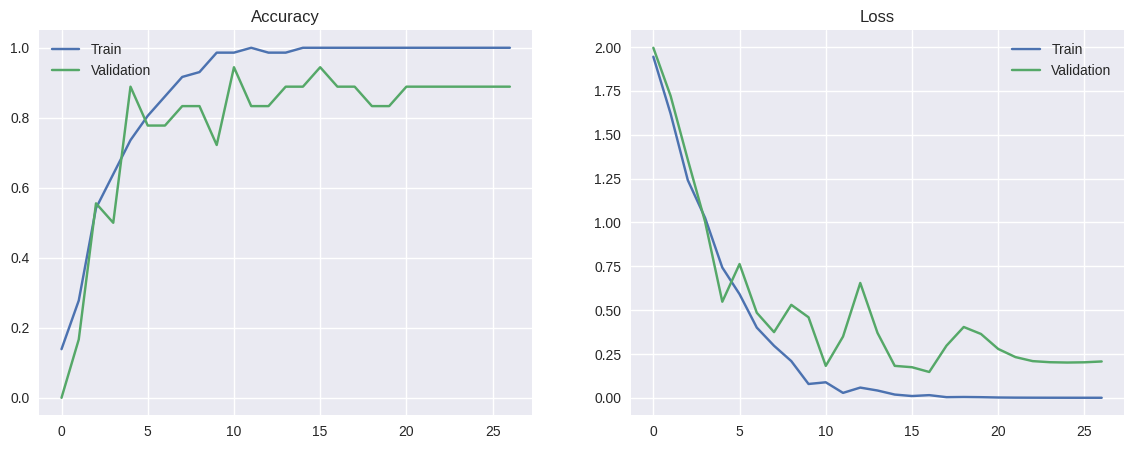

In [19]:
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.legend()
plt.show()

**Task 5: Evaluate the Model**

In [33]:
#TASK 5: Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8000 - loss: 0.8636
✅ Test Accuracy: 0.8000 | Test Loss: 0.8636


**Task 6: Save and Load the Model**

In [23]:
model.save('fruit_classifier_final.h5')
print("✅ Model saved as fruit_classifier_final.h5")
loaded_model = tf.keras.models.load_model('fruit_classifier_final.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"✅ Loaded model Test Accuracy: {loaded_acc:.4f}")

✅ Model saved as fruit_classifier_final.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.8000 - loss: 0.6924
✅ Loaded model Test Accuracy: 0.8000


**Task 7: Predictions and Classification Report**

In [34]:
# TASK 7: Classification Report on Test
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = []
for _, labels in test_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

print("="*70)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*70)
print(classification_report(true_labels, predicted_labels,
                           target_names=class_names, digits=2))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.80        30
   macro avg       0.81      0.80      0.79        30
weighted avg       0.81      0.80      0.79        30

